Instructions: Have all the code for all the questions in one Jupyter notebook and upload the file at the time of submission. I will only consider this file format for grading. So, after you uploaded the file, check the file extension and if it is not an ipynb, then upload the right file.

Consider heart.csv dataset that is in Normal test folder and do the following:

1) Apply SVM along with GridSearchCV to determine the best parameters for kernel=("sigmoid", "rbf", linear) and C =(1, 5, 10). Use the best parameters from the search and build an SVC model and compute confusion matrix, classification report and accuracy.

2) Likewise, use GridSearchCV to find the best number of trees for Random Forest and then build Random Forest Classifier and compute confusion matrix, classification report and accuracy.

Also read about RandomSearchCV.  And explain the difference between RandomSearchCV and GridSearchCV.

## 1. SVM

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('heart.csv')

In [130]:
df.shape

(303, 14)

In [131]:
# Select the features and target
xc = df[["age","gender", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "trestbps", "chol", "thalach", "oldpeak"]]
yc = df['target']

In [132]:
# Transform the data
from sklearn.model_selection import train_test_split

xc_train, xc_test, yc_train, yc_test = train_test_split(xc, yc, test_size = 0.20)

scaler = StandardScaler().fit(xc_train) 

xc_train = scaler.transform(xc_train) 

xc_test = scaler.transform(xc_test)

In [133]:
# Perform the grid search to find the best parameters for SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

parameters = {'kernel':["sigmoid", "rbf", "linear"], 'C':[1, 5, 10]}

svc = SVC()

# Divide into 3 groups.
# 3 kernels, 3 C values = 9 candidates
# Total fits is 27
clf = GridSearchCV(svc, param_grid = parameters, cv = 3, verbose=True, n_jobs = -1)

final_clf = clf.fit(xc_train, yc_train)

print(sorted(final_clf.cv_results_.keys()))
print(final_clf.best_estimator_)
print(final_clf.best_params_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
['mean_fit_time', 'mean_score_time', 'mean_test_score', 'param_C', 'param_kernel', 'params', 'rank_test_score', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'std_fit_time', 'std_score_time', 'std_test_score']
SVC(C=1, kernel='sigmoid')
{'C': 1, 'kernel': 'sigmoid'}


In [144]:
# Do the fit with the best parameters and print the accuracy
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import metrics

svc = SVC(kernel="linear", degree=1) 
svc.fit(xc_train, yc_train) 

y_pred = svc.predict(xc_test)

cm_tree = confusion_matrix(yc_test,y_pred)
print(cm_tree)
print(classification_report(yc_test,y_pred))


print("Accuracy is:", metrics.accuracy_score(yc_test, y_pred)*100)

[[27  4]
 [ 2 28]]
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        31
           1       0.88      0.93      0.90        30

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

Accuracy is: 90.1639344262295


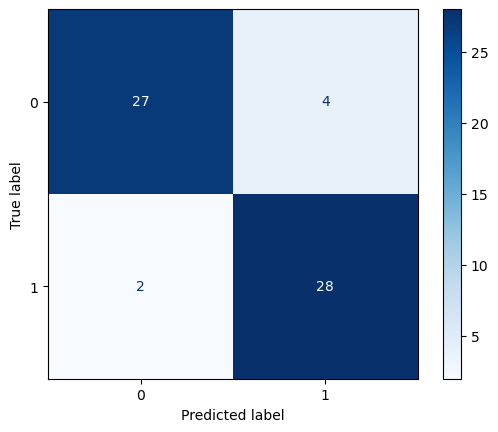

In [146]:
# Print the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp.plot(cmap="Blues")
plt.show()

<div class="alert alert-block alert-info">
<b>Conclusion:</b> I settled on a linear SVC kernel with degree 1 to yield an accuracy of 90%.
</div>

## 2. Random Forest

In [152]:
from sklearn.ensemble import RandomForestClassifier

rf_grid = RandomForestClassifier()
gr_space = {
    'max_depth': [3,5,7,10],
    'n_estimators': [50, 100, 200, 300],
    'max_features': [10, 20, 30, 40],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(rf_grid, gr_space, cv = 3, scoring='accuracy', verbose = 3)
model_grid = grid.fit(xc, yc)

print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))

Fitting 3 folds for each of 192 candidates, totalling 576 fits
[CV 1/3] END max_depth=3, max_features=10, min_samples_leaf=1, n_estimators=50;, score=0.842 total time=   0.0s
[CV 2/3] END max_depth=3, max_features=10, min_samples_leaf=1, n_estimators=50;, score=0.851 total time=   0.0s
[CV 3/3] END max_depth=3, max_features=10, min_samples_leaf=1, n_estimators=50;, score=0.782 total time=   0.0s
[CV 1/3] END max_depth=3, max_features=10, min_samples_leaf=1, n_estimators=100;, score=0.832 total time=   0.0s
[CV 2/3] END max_depth=3, max_features=10, min_samples_leaf=1, n_estimators=100;, score=0.861 total time=   0.0s
[CV 3/3] END max_depth=3, max_features=10, min_samples_leaf=1, n_estimators=100;, score=0.762 total time=   0.0s
[CV 1/3] END max_depth=3, max_features=10, min_samples_leaf=1, n_estimators=200;, score=0.812 total time=   0.1s
[CV 2/3] END max_depth=3, max_features=10, min_samples_leaf=1, n_estimators=200;, score=0.881 total time=   0.1s
[CV 3/3] END max_depth=3, max_featur

<div class="alert alert-block alert-info">
<b>Conclusion:</b> Best hyperparameters are {'max_depth': 3, 'max_features': 10, 'min_samples_leaf': 2, 'n_estimators': 100}<br/>
    Best score is: 0.8250825082508252
</div>

Accuracy is: 90.1639344262295
[[27  4]
 [ 2 28]]
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        31
           1       0.88      0.93      0.90        30

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



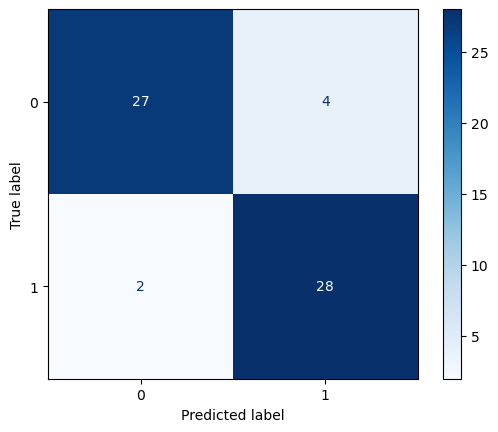

In [156]:
rfc = RandomForestClassifier(max_depth=3, max_features=10, min_samples_leaf=2, n_estimators=100)
rfc.fit(xc_train, yc_train)

rfc_predict = rfc.predict(xc_test)     

print("Accuracy is:", metrics.accuracy_score(yc_test,rfc_predict)*100)  

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_rf = confusion_matrix(yc_test, rfc_predict)

print(cm_rf)
print(classification_report(yc_test, rfc_predict))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Blues")
plt.show()

<div class="alert alert-block alert-info">
<b>Conclusion:</b> The final accuracy is 90%
</div>

## 2b. RandomSearchCV vs GridSearchCV 

<div class="alert alert-block alert-info">
<b>Conclusion:</b> In GridSearchCV, all parameters are tested and it chooses the best outcome. It will have a longer run-time however. <br/>
    For RandomSearch to be effective, choose n_iteration >= 100
</div>